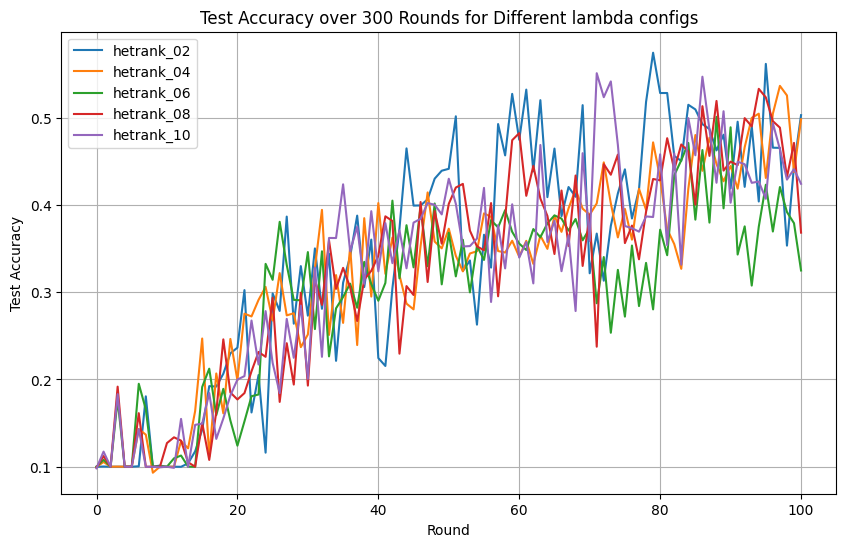

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 定义文件末尾的数字列表
suffixes = ['02', '04' ,'06', '08', '10']

# 创建一个图形，设置画布大小
plt.figure(figsize=(10, 6))

# 遍历每个文件后缀
for suffix in suffixes:
    file_name = f'hetrank_{suffix}.csv'
    
    # 检查文件是否存在，防止因为部分文件缺失报错
    if os.path.exists(file_name):
        # 读取CSV，跳过前两行（即跳过包含Config的一行和空行）
        df = pd.read_csv(file_name, skiprows=2)
        
        # 获取第一列的数据 (accuracy)
        # 也可以直接用 df['accuracy']
        accuracy = df.iloc[:, 0] 
        
        # 绘制折线图，设置图例标签为对应的文件名
        plt.plot(accuracy, label=f'hetrank_{suffix}')
    else:
        print(f"警告：找不到文件 {file_name}，请检查路径。")

# 设置图表的标题和坐标轴标签
plt.title('Test Accuracy over 300 Rounds for Different lambda configs')
plt.xlabel('Round')
plt.ylabel('Test Accuracy')

# 显示图例 (默认会自动为不同折线分配不同颜色)
plt.legend()

# 开启网格线以便于更好地观察数据变化
plt.grid(True)

# 保存图表为高清图片
plt.savefig('accuracy_comparison.png', dpi=300, bbox_inches='tight')

# 显示图表
plt.show()

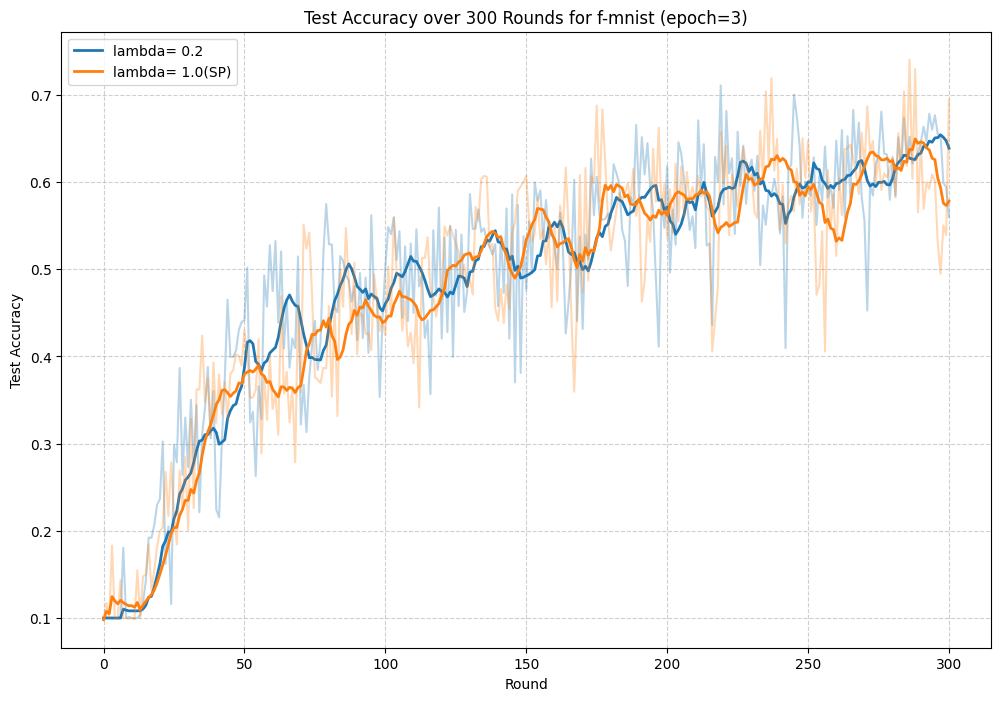

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 定义文件末尾的数字列表
suffixes = ['02', '10']

# 设置平滑窗口大小
window_size = 10 

# 创建画布，稍微放大一点以容纳更多信息
plt.figure(figsize=(12, 8))

# 遍历每个文件后缀
for suffix in suffixes:
    file_name = f'hetrank_{suffix}.csv'
    
    if os.path.exists(file_name):
        # 读取CSV，跳过前两行配置
        df = pd.read_csv(file_name, skiprows=2)
        accuracy = df.iloc[:, 0]
        
        # 计算滑动平均
        smoothed_accuracy = accuracy.rolling(window=window_size, min_periods=1).mean()
        
        # 1. 先画平滑后的线，并获取系统自动分配的颜色
        # 这样可以保证原始数据的半透明线和这条实线颜色一致
        if suffix == '10':
            line = plt.plot(smoothed_accuracy, linewidth=2, label=f'lambda= {float(suffix)/10}(SP)')
        else:
            line = plt.plot(smoothed_accuracy, linewidth=2, label=f'lambda= {float(suffix)/10}')
        current_color = line[0].get_color()
        
        # 2. 用相同的颜色画出原始数据的半透明线
        # 我们这里不给它加 label，否则图例会多出整整一倍，显得拥挤
        plt.plot(accuracy, color=current_color, alpha=0.3)
        
    else:
        print(f"警告：找不到文件 {file_name}，请检查路径。")

# 设置标题和标签
plt.title(f'Test Accuracy over 300 Rounds for f-mnist (epoch=3)')
plt.xlabel('Round')
plt.ylabel('Test Accuracy')

# 显示图例
plt.legend()

# 开启网格线
plt.grid(True, linestyle='--', alpha=0.6)

# 保存高清图片
plt.savefig('all_hetrank_comparison.png', dpi=300, bbox_inches='tight')

# 显示图表
plt.show()